> **Disclaimer**  
> All notebooks in this repository were executed using Google Colab.  
> The dataset is stored in Google Drive and is not included in this repository due to privacy considerations.  
> File paths may need to be updated to match your own Google Drive directory structure before running the code.

In [1]:
# Install required libraries
!pip install numpy pandas matplotlib seaborn statsmodels scipy

In [2]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import shapiro, levene, bartlett, zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dir_name = '/content/drive/MyDrive/Thesis/Data/Multivariate Data/'
df = pd.read_csv(f"{dir_name}[Raw]Multivariate_Data_Monthly.csv")
df.head()

,Year,Month,Residential Monthly Average,Commercial Monthly Average,Government Monthly Average,RAINFALL,TMAX,TMIN,TMEAN,WIND_SPEED,WIND_DIRECTION,RH
0,2010,1,4940168.0,702499.0,156935.0,5.080645,30.564516,23.909677,27.258065,2.354839,213.225806,84.258065
1,2010,2,3996492.0,601294.0,137278.0,0.571429,32.521429,23.550000,28.053571,2.607143,176.071429,78.071429
2,2010,3,4423759.0,654733.0,145150.0,1.706452,33.493548,24.390323,28.954839,2.741935,159.354839,78.096774
3,2010,4,4605206.0,672214.0,141869.0,4.133333,32.516667,24.800000,28.680000,2.100000,245.666667,82.166667
4,2010,5,4475865.0,642270.0,137791.0,1.848387,32.822581,25.522581,29.193548,1.903226,164.516129,83.064516


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         157 non-null    int64  
 1   Month                        157 non-null    int64  
 2   Residential Monthly Average  157 non-null    float64
 3   Commercial Monthly Average   157 non-null    float64
 4   Government Monthly Average   157 non-null    float64
 5   RAINFALL                     157 non-null    float64
 6   TMAX                         157 non-null    float64
 7   TMIN                         157 non-null    float64
 8   TMEAN                        157 non-null    float64
 9   WIND_SPEED                   157 non-null    float64
 10  WIND_DIRECTION               157 non-null    float64
 11  RH                           157 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 14.8 KB
None


# Assumption Testing of Data

#### Normality Test
- Check if the data follows a normal distribution.

In [ ]:
# Define a function for Shapiro-Wilk Test
def test_normality(series):
    stat, p = shapiro(series)
    print(f"Shapiro-Wilk Test: W={stat}, p={p}")
    if p > 0.05:
        print("Data appears to be normally distributed.\n")
    else:
        print("Data does not appear to be normally distributed.\n")

# Apply to water consumption and weather parameters
for col in ['Residential Monthly Average', 'Commercial Monthly Average',
            'Government Monthly Average', 'TMEAN', 'RH']: #RH means Relative Humidity
    print(f"Testing normality for {col}")
    test_normality(df[col])


Testing normality for Residential Monthly Average
Shapiro-Wilk Test: W=0.9908944408422402, p=0.41283992848779394
Data appears to be normally distributed.

Testing normality for Commercial Monthly Average
Shapiro-Wilk Test: W=0.9351456362441682, p=1.42276621236351e-06
Data does not appear to be normally distributed.

Testing normality for Government Monthly Average
Shapiro-Wilk Test: W=0.9687462716078319, p=0.0012524031936219948
Data does not appear to be normally distributed.

Testing normality for TMEAN
Shapiro-Wilk Test: W=0.0728197949497873, p=3.825662302696829e-27
Data does not appear to be normally distributed.

Testing normality for RH
Shapiro-Wilk Test: W=0.1258290846068687, p=1.6121348459618344e-26
Data does not appear to be normally distributed.



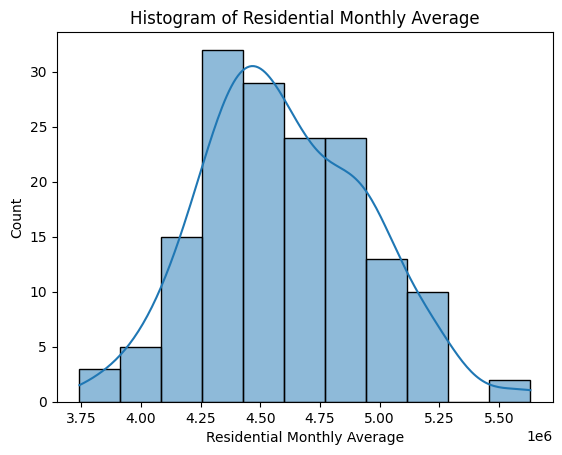

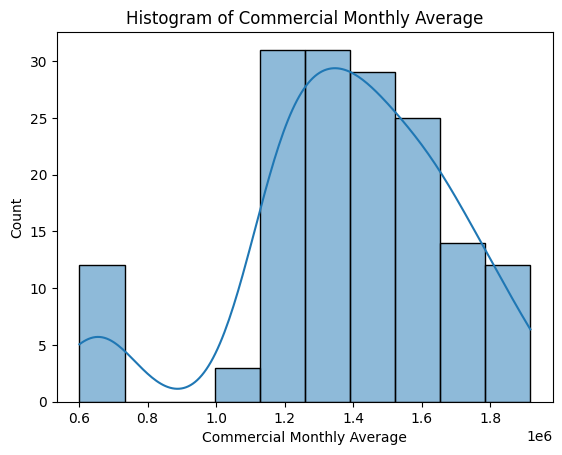

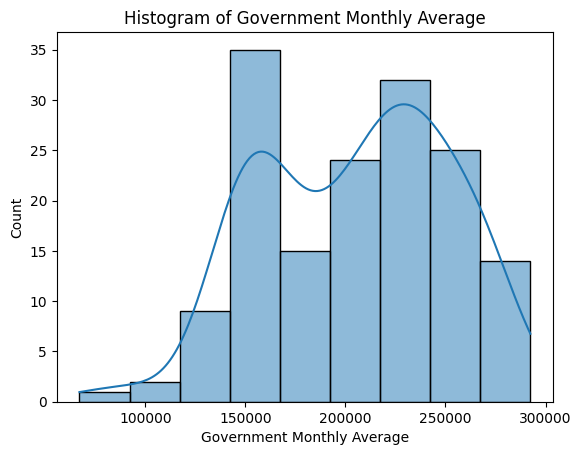

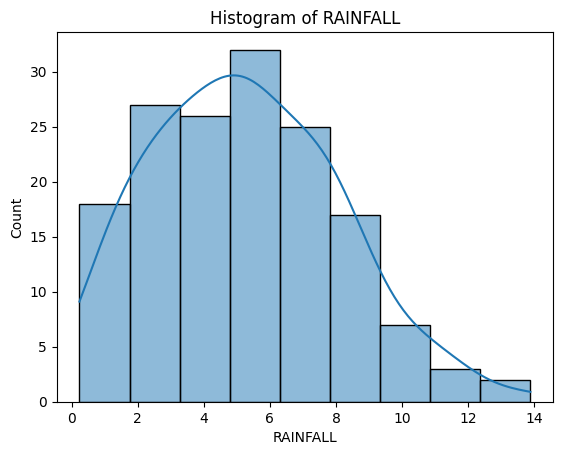

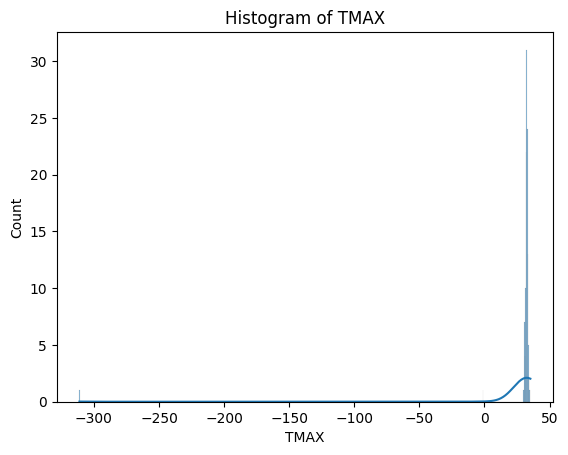

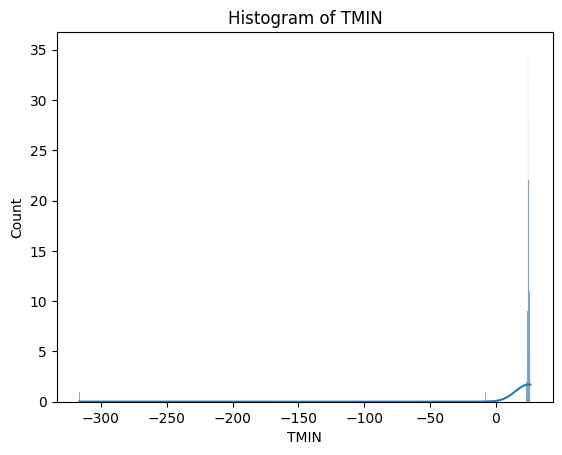

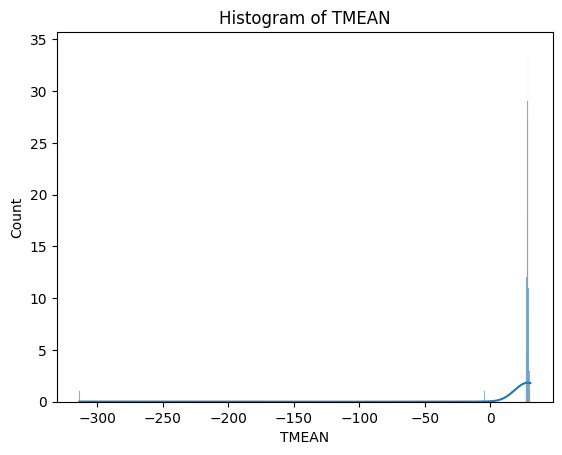

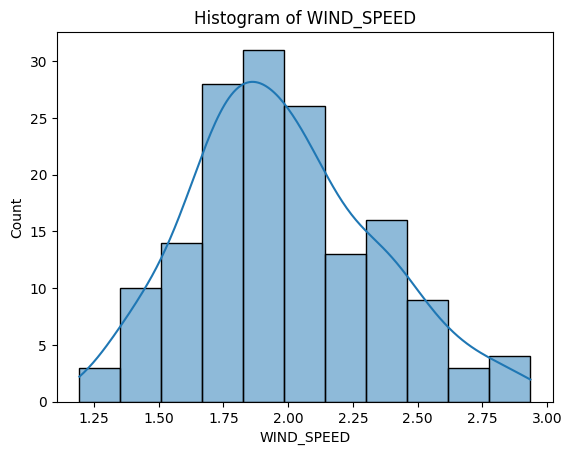

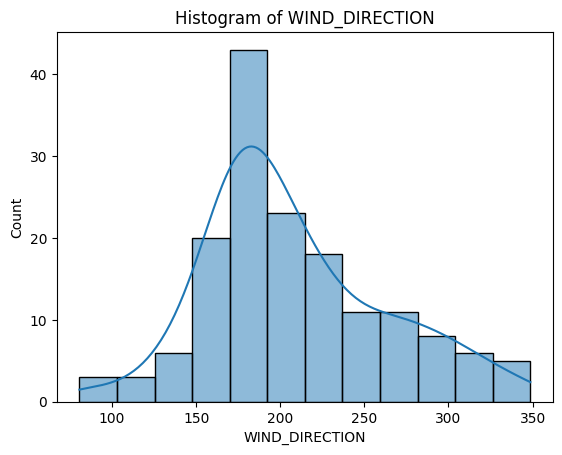

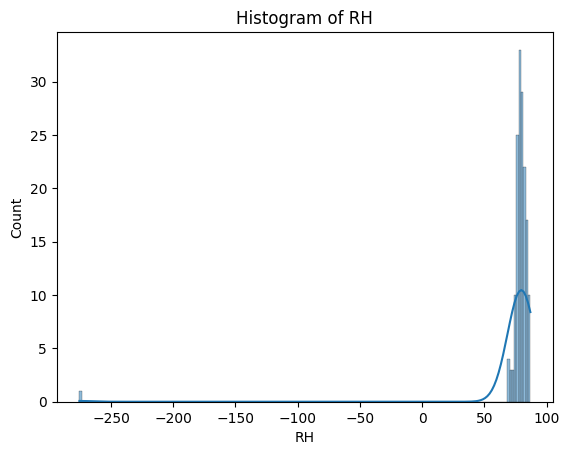

In [ ]:
# Plot histograms
for col in ['Residential Monthly Average', 'Commercial Monthly Average',
            'Government Monthly Average', 'RAINFALL', 'TMAX', 'TMIN', 'TMEAN',
            'WIND_SPEED', 'WIND_DIRECTION', 'RH']:
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

# Normality Test Results (Shapiro–Wilk Test)

## Method
The **Shapiro–Wilk test** was used to assess whether each variable follows a normal distribution.

**Hypotheses:**
- **Null hypothesis (H₀):** Data is normally distributed
- **Alternative hypothesis (H₁):** Data is not normally distributed

**Decision rule:**
- If **p ≥ 0.05** → Fail to reject H₀ → Data is normally distributed
- If **p < 0.05** → Reject H₀ → Data is not normally distributed

---

# Results

## Residential Monthly Average
- **W statistic:** 0.9909  
- **p-value:** 0.4128  
- **Conclusion:** Normally distributed  

Interpretation:  
The residential monthly average follows a normal distribution and is suitable for parametric statistical methods.

---

## Commercial Monthly Average
- **W statistic:** 0.9351  
- **p-value:** 1.42 × 10⁻⁶  
- **Conclusion:** Not normally distributed  

Interpretation:  
The commercial monthly average significantly deviates from normality.

---

## Government Monthly Average
- **W statistic:** 0.9687  
- **p-value:** 0.00125  
- **Conclusion:** Not normally distributed  

Interpretation:  
The government monthly average does not follow a normal distribution.

---

## Mean Temperature (TMEAN)
- **W statistic:** 0.0728  
- **p-value:** 3.83 × 10⁻²⁷  
- **Conclusion:** Not normally distributed  

Interpretation:  
Mean temperature shows a very strong deviation from normality.

---

## Relative Humidity (RH)
- **W statistic:** 0.1258  
- **p-value:** 1.61 × 10⁻²⁶  
- **Conclusion:** Not normally distributed  

Interpretation:  
Relative humidity is highly non-normal.

---

# Summary Table

| Variable | W Statistic | p-value | Normally Distributed |
|---|---|---|---|
| Residential Monthly Average | 0.9909 | 0.4128 | Yes |
| Commercial Monthly Average | 0.9351 | 1.42 × 10⁻⁶ | No |
| Government Monthly Average | 0.9687 | 0.00125 | No |
| TMEAN | 0.0728 | 3.83 × 10⁻²⁷ | No |
| RH | 0.1258 | 1.61 × 10⁻²⁶ | No |

---

# Implications for Machine Learning Models (CNN, LSTM, CNN-LSTM)

The selected machine learning models:

- Convolutional Neural Network (CNN)
- Long Short-Term Memory (LSTM)
- Hybrid CNN-LSTM

are **robust to non-normal data**.

## Reason

Neural networks do not assume any specific statistical distribution because:

- They are **non-parametric models**
- They learn patterns directly from data using optimization (gradient descent)
- They do not require assumptions such as normality, linearity, or homoscedasticity

Unlike parametric methods (e.g., linear regression), neural networks are distribution-independent.

---

## What matters more than normality

For CNN, LSTM, and CNN-LSTM, the following are more important:

- Feature scaling (normalization or standardization)
- Temporal structure (for LSTM and CNN-LSTM)
- Sufficient training data
- Proper train-test split
- Avoiding data leakage

Recommended preprocessing:
- MinMax scaling or standardization of features such as TMEAN and RH

---

# Conclusion

- Most variables are not normally distributed.
- This does not negatively affect CNN, LSTM, or CNN-LSTM models.
- These models are suitable for non-normal, nonlinear, and complex time-series data.
- Feature scaling is recommended, but normality is not required.

#### Stationarity Test
- Check if the data is stationary.

In [7]:
# Define Augmented Dickey-Fuller (ADF) test
def adf_test(series, column_name):
    result = adfuller(series, autolag='AIC')
    print(f"Column: {column_name}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data is stationary (reject null hypothesis).\n")
    else:
        print("Data is not stationary.\n")

# Apply to time series columns
columns_to_test = [
    'Residential Monthly Average', 'Commercial Monthly Average',
    'Government Monthly Average', 'TMEAN', 'RH']

for col in columns_to_test:
    adf_test(df[col], col)


Column: Residential Monthly Average
ADF Statistic: -1.3051134088640632
p-value: 0.6268296879227839
Data is not stationary.

Column: Commercial Monthly Average
ADF Statistic: -0.5379987466986094
p-value: 0.8843855869048944
Data is not stationary.

Column: Government Monthly Average
ADF Statistic: -1.3805057590162044
p-value: 0.5915854035832402
Data is not stationary.

Column: TMEAN
ADF Statistic: -12.50835704322162
p-value: 2.7088126392871844e-23
Data is stationary (reject null hypothesis).

Column: RH
ADF Statistic: -11.758440425861425
p-value: 1.1634325269682107e-21
Data is stationary (reject null hypothesis).



#### Trend and Seasonality Analysis
- Decompose the time series.

STL Decomposition for Residential Monthly Average


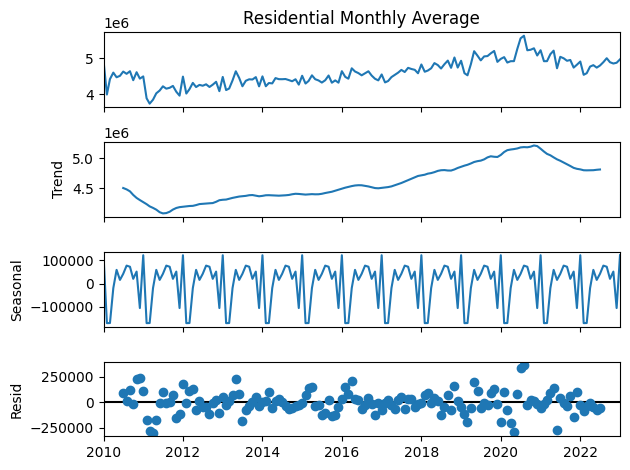

STL Decomposition for Commercial Monthly Average


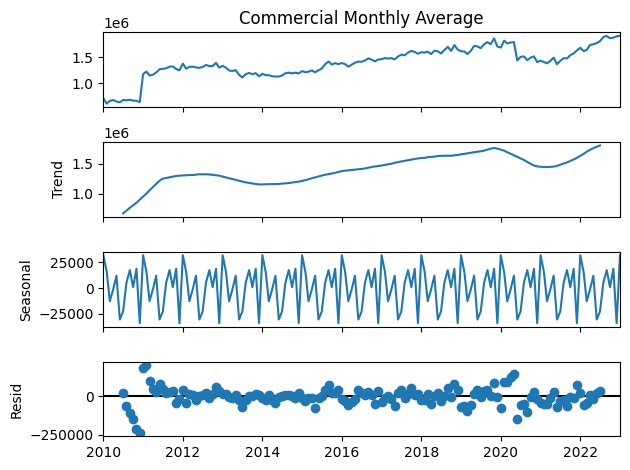

STL Decomposition for Government Monthly Average


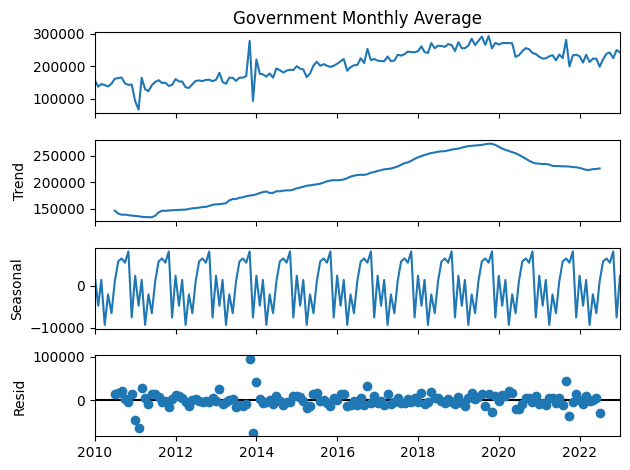

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Create a datetime index using Year and Month
df['Period'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

# Set the Period as the index
df.set_index('Period', inplace=True)

# List of columns to decompose
columns_to_decompose = [
    'Residential Monthly Average',
    'Commercial Monthly Average',
    'Government Monthly Average'
]

# Perform STL decomposition for each column
for col in columns_to_decompose:
    # Extract the monthly time series for the column
    monthly_data = df[col]

    # Decompose the time series
    result = seasonal_decompose(monthly_data, model='additive', period=12)

    # Plot the decomposition
    print(f"STL Decomposition for {col}")
    result.plot()
    plt.tight_layout()
    plt.show()


#### Autocorrelation Function (ACF) & Partial Autocorrelation Function (PACF)
- Visualize lag relationships.

Plotting ACF and PACF for Residential Monthly Average


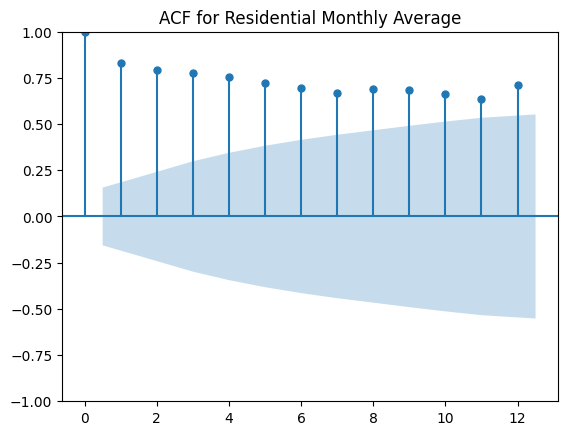

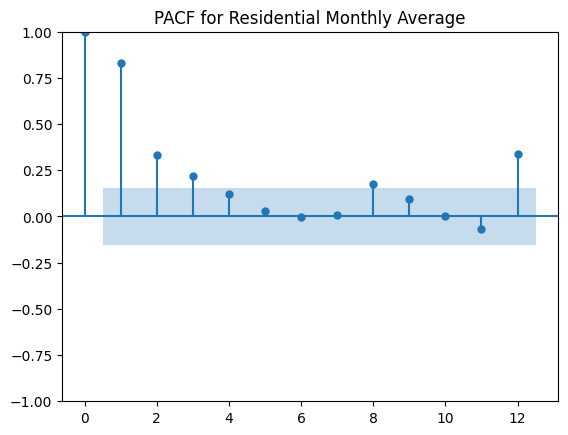

Plotting ACF and PACF for Commercial Monthly Average


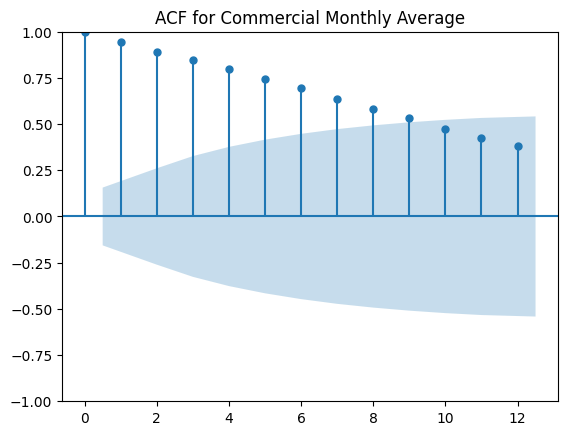

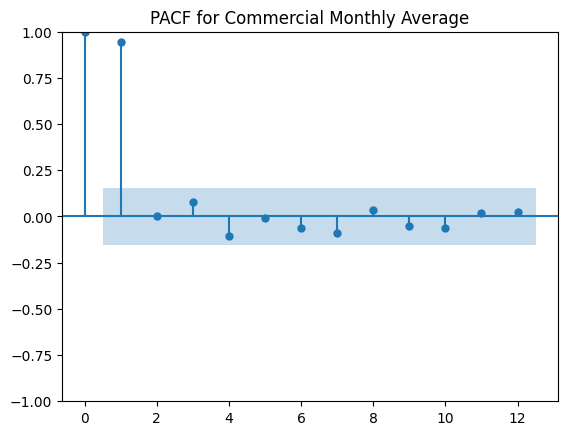

Plotting ACF and PACF for Government Monthly Average


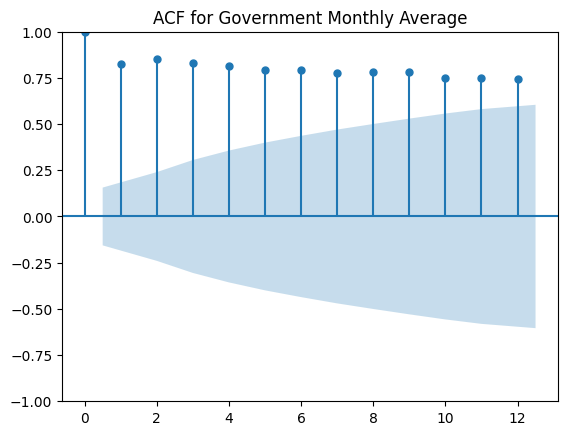

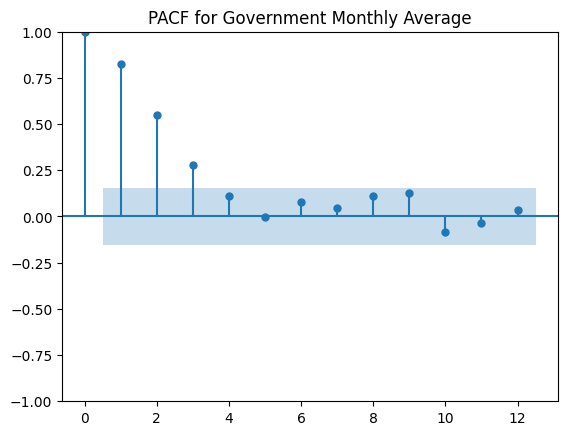

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure only relevant columns are selected
monthly_data = df[['Residential Monthly Average',
                   'Commercial Monthly Average',
                   'Government Monthly Average']]

# List of columns to analyze
columns_to_analyze = ['Residential Monthly Average',
                      'Commercial Monthly Average',
                      'Government Monthly Average']

# Plot ACF and PACF for each column
for col in columns_to_analyze:
    print(f"Plotting ACF and PACF for {col}")

    # Drop missing values if any
    column_data = monthly_data[col].dropna()

    # Plot ACF
    plot_acf(column_data, lags=12)
    plt.title(f"ACF for {col}")
    plt.show()

    # Plot PACF
    plot_pacf(column_data, lags=12, method='ywm')
    plt.title(f"PACF for {col}")
    plt.show()
